In [1]:
#Mengimport Library yang dibutuhkan untuk analisis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dateutil import parser
import datetime
import duckdb as db
from geopy.geocoders import Nominatim
import pytz
import seaborn as sns
import plotly as ply
import plotly.graph_objs as go

In [2]:
#Load dataframe
cvd_df = pd.read_csv("E:\Project Python Data Analyst\File csv latihan\covid_19_indonesia_time_series_all.csv")

pd.set_option('display.max_columns', None)
cvd_df.head(15)

,Date,Location ISO Code,Location,New Cases,New Deaths,New Recovered,New Active Cases,Total Cases,Total Deaths,Total Recovered,Total Active Cases,Location Level,City or Regency,Province,Country,Continent,Island,Time Zone,Special Status,Total Regencies,Total Cities,Total Districts,Total Urban Villages,Total Rural Villages,Area (km2),Population,Population Density,Longitude,Latitude,New Cases per Million,Total Cases per Million,New Deaths per Million,Total Deaths per Million,Total Deaths per 100rb,Case Fatality Rate,Case Recovered Rate,Growth Factor of New Cases,Growth Factor of New Deaths
0,3/1/2020,ID-JK,DKI Jakarta,2,0,0,2,39,20,75,-56,Province,NaN,DKI Jakarta,Indonesia,Asia,Jawa,UTC+07:00,Daerah Khusus Ibu Kota,1,5.0,44,267.0,NaN,664,10846145,16334.31,106.836118,-6.204699,0.18,3.60,0.00,1.84,0.18,51.28%,192.31%,NaN,NaN
1,3/2/2020,ID-JK,DKI Jakarta,2,0,0,2,41,20,75,-54,Province,NaN,DKI Jakarta,Indonesia,Asia,Jawa,UTC+07:00,Daerah Khusus Ibu Kota,1,5.0,44,267.0,NaN,664,10846145,16334.31,106.836118,-6.204699,0.18,3.78,0.00,1.84,0.18,48.78%,182.93%,1.0,1.0
2,3/2/2020,IDN,Indonesia,2,0,0,2,2,0,0,2,Country,NaN,NaN,Indonesia,Asia,NaN,NaN,NaN,416,98.0,7230,8488.0,74953.0,1916907,265185520,138.34,113.921327,-0.789275,0.01,0.01,0.00,0.00,0.00,0.00%,0.00%,NaN,NaN
3,3/2/2020,ID-RI,Riau,1,0,0,1,1,0,1,0,Province,NaN,Riau,Indonesia,Asia,Sumatera,UTC+07:00,NaN,10,2.0,169,268.0,1591.0,87024,6074100,69.80,101.805109,0.511648,0.16,0.16,0.00,0.00,0.00,0.00%,100.00%,NaN,NaN
4,3/3/2020,ID-JK,DKI Jakarta,2,0,0,2,43,20,75,-52,Province,NaN,DKI Jakarta,Indonesia,Asia,Jawa,UTC+07:00,Daerah Khusus Ibu Kota,1,5.0,44,267.0,NaN,664,10846145,16334.31,106.836118,-6.204699,0.18,3.96,0.00,1.84,0.18,46.51%,174.42%,1.0,1.0
5,3/3/2020,IDN,Indonesia,0,0,0,0,2,0,0,2,Country,NaN,NaN,Indonesia,Asia,NaN,NaN,NaN,416,98.0,7230,8488.0,74953.0,1916907,265185520,138.34,113.921327,-0.789275,0.00,0.01,0.00,0.00,0.00,0.00%,0.00%,0.0,1.0
6,3/3/2020,ID-JB,Jawa Barat,1,1,0,0,1,1,60,-60,Province,NaN,Jawa Barat,Indonesia,Asia,Jawa,UTC+07:00,NaN,18,9.0,627,645.0,5312.0,35378,45161325,1276.55,107.603708,-6.920432,0.02,0.02,0.02,0.02,0.00,100.00%,6000.00%,NaN,NaN
7,3/3/2020,ID-RI,Riau,0,0,0,0,1,0,1,0,Province,NaN,Riau,Indonesia,Asia,Sumatera,UTC+07:00,NaN,10,2.0,169,268.0,1591.0,87024,6074100,69.80,101.805109,0.511648,0.00,0.16,0.00,0.00,0.00,0.00%,100.00%,0.0,1.0
8,3/4/2020,ID-JK,DKI Jakarta,2,0,0,2,45,20,75,-50,Province,NaN,DKI Jakarta,Indonesia,Asia,Jawa,UTC+07:00,Daerah Khusus Ibu Kota,1,5.0,44,267.0,NaN,664,10846145,16334.31,106.836118,-6.204699,0.18,4.15,0.00,1.84,0.18,44.44%,166.67%,1.0,1.0
9,3/4/2020,IDN,Indonesia,0,0,0,0,2,0,0,2,Country,NaN,NaN,Indonesia,Asia,NaN,NaN,NaN,416,98.0,7230,8488.0,74953.0,1916907,265185520,138.34,113.921327,-0.789275,0.00,0.01,0.00,0.00,0.00,0.00%,0.00%,1.0,1.0


In [3]:
cvd_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31822 entries, 0 to 31821
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Date                         31822 non-null  object 
 1   Location ISO Code            31822 non-null  object 
 2   Location                     31822 non-null  object 
 3   New Cases                    31822 non-null  int64  
 4   New Deaths                   31822 non-null  int64  
 5   New Recovered                31822 non-null  int64  
 6   New Active Cases             31822 non-null  int64  
 7   Total Cases                  31822 non-null  int64  
 8   Total Deaths                 31822 non-null  int64  
 9   Total Recovered              31822 non-null  int64  
 10  Total Active Cases           31822 non-null  int64  
 11  Location Level               31822 non-null  object 
 12  City or Regency              0 non-null      float64
 13  Province        

In [4]:
#Mengecek data null/NaN
missing_data = cvd_df.isnull().sum()
missing_data

Date                               0
Location ISO Code                  0
Location                           0
New Cases                          0
New Deaths                         0
New Recovered                      0
New Active Cases                   0
Total Cases                        0
Total Deaths                       0
Total Recovered                    0
Total Active Cases                 0
Location Level                     0
City or Regency                31822
Province                         929
Country                            0
Continent                          0
Island                           929
Time Zone                        929
Special Status                 27264
Total Regencies                    0
Total Cities                     901
Total Districts                    0
Total Urban Villages             904
Total Rural Villages             929
Area (km2)                         0
Population                         0
Population Density                 0
L

In [5]:
#Membuat fungsi untuk query SQL
def query(sql_query:str) -> pd.DataFrame:
    return db.sql(sql_query).df()

In [6]:
#Mengubah Dtype pada kolom 'Date' menjadi 'datetime64'
cvd_df['Date'] = cvd_df['Date'].map(parser.parse)
cvd_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31822 entries, 0 to 31821
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Date                         31822 non-null  datetime64[ns]
 1   Location ISO Code            31822 non-null  object        
 2   Location                     31822 non-null  object        
 3   New Cases                    31822 non-null  int64         
 4   New Deaths                   31822 non-null  int64         
 5   New Recovered                31822 non-null  int64         
 6   New Active Cases             31822 non-null  int64         
 7   Total Cases                  31822 non-null  int64         
 8   Total Deaths                 31822 non-null  int64         
 9   Total Recovered              31822 non-null  int64         
 10  Total Active Cases           31822 non-null  int64         
 11  Location Level               31822 non-nu

In [7]:
#Membuat fungsi untuk mencari lokasi berdasarkan koordinat menggunakan modul Geopy/Geolocator
def search_city (latitude:float, longitude:float)-> str:
    geolocator = Nominatim(user_agent="CvdData", timeout=10)
    coordinates = f'{latitude}, {longitude}'
    location = geolocator.reverse(coordinates)
    return location.raw.get('address',{}).get('county','')

In [8]:
null_city = list(cvd_df[['Latitude', 'Longitude']].values)
city_code = {}

for counter, location in enumerate(null_city, start=1):
    location_key = f'{location[0]}/{location[1]}'
    if location_key not in city_code:
        city = search_city(location[0], location[1])
        city_code[location_key] = city
    print(f'Detection location {counter} for {location} -> {city_code[location_key]}')

Detection location 1 for [ -6.20469899 106.8361183 ] -> 
Detection location 2 for [ -6.20469899 106.8361183 ] -> 
Detection location 3 for [ -0.789275 113.921327] -> Kapuas
Detection location 4 for [  0.51164785 101.8051092 ] -> Siak
Detection location 5 for [ -6.20469899 106.8361183 ] -> 
Detection location 6 for [ -0.789275 113.921327] -> Kapuas
Detection location 7 for [ -6.92043208 107.6037083 ] -> 
Detection location 8 for [  0.51164785 101.8051092 ] -> Siak
Detection location 9 for [ -6.20469899 106.8361183 ] -> 
Detection location 10 for [ -0.789275 113.921327] -> Kapuas
Detection location 11 for [ -6.92043208 107.6037083 ] -> 
Detection location 12 for [  0.51164785 101.8051092 ] -> Siak
Detection location 13 for [ -6.20469899 106.8361183 ] -> 
Detection location 14 for [ -0.789275 113.921327] -> Kapuas
Detection location 15 for [ -6.92043208 107.6037083 ] -> 
Detection location 16 for [  0.51164785 101.8051092 ] -> Siak
Detection location 17 for [ -6.45673639 106.1090043 ] -> 

In [9]:
#Menyimpan hasil pencarian ke bentuk json
import json

with open('city_code.json', 'w') as outfile:
    json.dump(city_code, outfile, indent=4)

In [10]:
with open ('city_code2.json', 'r') as my_city:
    city_code = json.load(my_city)
city_code

{'-6.204698991/106.8361183': 'Jakarta Pusat',
 '-0.789275/113.921327': 'Kapuas',
 '0.511647851/101.8051092': 'Siak',
 '-6.920432083/107.6037083': 'Bandung',
 '-6.456736388/106.1090043': 'Lebak',
 '-7.259097177/110.2011149': 'Temanggung',
 '-4.124688793/122.070311': 'Konawe Selatan',
 '-8.369471688/115.1317136': 'Tabanan',
 '0.45385803/116.4684405': 'Kutai Timur',
 '-7.89450185/110.4448783': 'Bantul',
 '2.191894453/99.05196442': 'Tapanuli Utara',
 '-7.723345579/112.7329414': 'Pasuruan',
 '3.916346/108.261746': 'Natuna',
 '-3.731080714/120.1620559': 'Compong',
 '-1.69769766/102.7236404': 'Tebo',
 '-3.192572/129.576792': 'Maluku Tengah',
 '-4.66620953/138.69603': 'Nduga',
 '0.212036949/127.5391072': 'Maluku Utara',
 '-3.216211808/104.1694647': 'Penukal Abab Lematang Ilir',
 '4.225614628/96.91052174': 'Aceh Tengah',
 '-1.602484653/113.4176536': 'Katingan',
 '-4.916792975/105.0214366': 'Lampung Utara',
 '-1.00413668/121.2010927': 'Sulawesi Tengah',
 '1.259638212/124.5212396': 'Minahasa Sela

In [11]:
#Mengisi nilai NaN pada kolom 'City or Regency'
cvd_df['City or Regency'] = cvd_df.apply(
    lambda rows: city_code.get(f"{rows['Latitude']}/{rows['Longitude']}", None) if pd.isna(rows["City or Regency"]) else rows["City or Regency"],
    axis=1)

In [12]:
cvd_df.head(15)

,Date,Location ISO Code,Location,New Cases,New Deaths,New Recovered,New Active Cases,Total Cases,Total Deaths,Total Recovered,Total Active Cases,Location Level,City or Regency,Province,Country,Continent,Island,Time Zone,Special Status,Total Regencies,Total Cities,Total Districts,Total Urban Villages,Total Rural Villages,Area (km2),Population,Population Density,Longitude,Latitude,New Cases per Million,Total Cases per Million,New Deaths per Million,Total Deaths per Million,Total Deaths per 100rb,Case Fatality Rate,Case Recovered Rate,Growth Factor of New Cases,Growth Factor of New Deaths
0,2020-03-01,ID-JK,DKI Jakarta,2,0,0,2,39,20,75,-56,Province,Jakarta Pusat,DKI Jakarta,Indonesia,Asia,Jawa,UTC+07:00,Daerah Khusus Ibu Kota,1,5.0,44,267.0,NaN,664,10846145,16334.31,106.836118,-6.204699,0.18,3.60,0.0,1.84,0.18,51.28%,192.31%,NaN,NaN
1,2020-03-02,ID-JK,DKI Jakarta,2,0,0,2,41,20,75,-54,Province,Jakarta Pusat,DKI Jakarta,Indonesia,Asia,Jawa,UTC+07:00,Daerah Khusus Ibu Kota,1,5.0,44,267.0,NaN,664,10846145,16334.31,106.836118,-6.204699,0.18,3.78,0.0,1.84,0.18,48.78%,182.93%,1.0,1.0
2,2020-03-02,IDN,Indonesia,2,0,0,2,2,0,0,2,Country,Kapuas,NaN,Indonesia,Asia,NaN,NaN,NaN,416,98.0,7230,8488.0,74953.0,1916907,265185520,138.34,113.921327,-0.789275,0.01,0.01,0.0,0.00,0.00,0.00%,0.00%,NaN,NaN
3,2020-03-02,ID-RI,Riau,1,0,0,1,1,0,1,0,Province,Siak,Riau,Indonesia,Asia,Sumatera,UTC+07:00,NaN,10,2.0,169,268.0,1591.0,87024,6074100,69.80,101.805109,0.511648,0.16,0.16,0.0,0.00,0.00,0.00%,100.00%,NaN,NaN
4,2020-03-03,ID-JK,DKI Jakarta,2,0,0,2,43,20,75,-52,Province,Jakarta Pusat,DKI Jakarta,Indonesia,Asia,Jawa,UTC+07:00,Daerah Khusus Ibu Kota,1,5.0,44,267.0,NaN,664,10846145,16334.31,106.836118,-6.204699,0.18,3.96,0.0,1.84,0.18,46.51%,174.42%,1.0,1.0


In [13]:
# Mengisi nilai NaN pada kolom provinsi dan pulau berdasarkan kolom kabupaten
regency_dict = {
    'Jakarta Pusat': {'Province': 'DKI Jakarta', 'Island': 'Jawa'},
    'Kapuas': {'Province': 'Kalimantan Tengah', 'Island': 'Kalimantan'},
    'Siak': {'Province': 'Riau', 'Island': 'Sumatera'},
    'Bandung': {'Province': 'Jawa Barat', 'Island': 'Jawa'},
    'Lebak': {'Province': 'Banten', 'Island': 'Jawa'},
    'Temanggung': {'Province': 'Jawa Tengah', 'Island': 'Jawa'},
    'Konawe Selatan': {'Province': 'Sulawesi Selatan', 'Island': 'Sulawesi'},
    'Tabanan': {'Province': 'Bali', 'Island': 'Bali'},
    'Kutai Timur': {'Province': 'Kalimantan Timur', 'Island': 'Kalimantan'},
    'Bantul': {'Province': 'Yogyakarta', 'Island': 'Jawa'},
    'Tapanuli Utara': {'Province': 'Sumatera Utara', 'Island': 'Sumatera'},
    'Pasuruan': {'Province': 'Jawa Timur', 'Island': 'Jawa'},
    'Natuna': {'Province': 'Kepulauan Riau', 'Island': 'Sumatera'},
    'Compong': {'Province': 'Sulawesi Selatan', 'Island': 'Sulawesi'},
    'Tebo': {'Province': 'Jambi', 'Island': 'Sumatera'},
    'Maluku Tengah': {'Province': 'Maluku', 'Island': 'Maluku'},
    'Nduga': {'Province': 'Papua Pegunungan', 'Island': 'Papua'},
    'Maluku Utara': {'Province': 'Maluku Utara', 'Island': 'Maluku'},
    'Penukal Abab Lematang Ilir': {'Province': 'Sumatera Selatan', 'Island': 'Sumatera'},
    'Aceh Tengah': {'Province': 'Aceh', 'Island': 'Sumatera'},
    'Katingan': {'Province': 'Kalimantan Tengah', 'Island': 'Kalimantan'},
    'Lampung Utara': {'Province': 'Lampung', 'Island': 'Sumatera'},
    'Sulawesi Tengah': {'Province': 'Sulawesi Tengah', 'Island': 'Sulawesi'},
    'Minahasa Selatan': {'Province': 'Sulawesi Utara', 'Island': 'Sulawesi'},
    'Padang': {'Province': 'Sumatera Barat', 'Island': 'Sumatera'},
    'Teluk Bintuni': {'Province': 'Papua Barat', 'Island': 'Papua'},
    'Kalimantan Utara': {'Province': 'Kalimantan Utara', 'Island': 'Kalimantan'},
    'Mamuju': {'Province': 'Sulawesi Barat', 'Island': 'Sulawesi'},
    'Sekadau': {'Province': 'Kalimantan Barat', 'Island': 'Kalimantan'},
    'Banjar': {'Province': 'Kalimantan Selatan', 'Island': 'Kalimantan'},
    'Bangka Belitung': {'Province': 'Kepulauan Bangka Belitung', 'Island': 'Sumatera'},
    'Bengkulu Tengah': {'Province': 'Bengkulu', 'Island': 'Sumatera'},
    'Sumbawa': {'Province': 'Nusa Tenggara Barat', 'Island': 'Nusa Tenggara'},
    'Ende': {'Province': 'Nusa Tenggara Timur', 'Island': 'Nusa tenggara'},
    'Boalemo': {'Province': 'Gorontalo', 'Island': 'Sulawesi'},
}

In [14]:
def fill_missing_values(row):
    if pd.isna(row['Province']):
        row['Province'] = regency_dict[row['City or Regency']]['Province']
    if pd.isna(row['Island']):
        row['Island'] = regency_dict[row['City or Regency']]['Island']
    
    return row

In [72]:
filled_data = cvd_df.apply(fill_missing_values, axis=1)
filled_data.head(15)

,Date,Location ISO Code,Location,New Cases,New Deaths,New Recovered,New Active Cases,Total Cases,Total Deaths,Total Recovered,Total Active Cases,Location Level,City or Regency,Province,Country,Continent,Island,Time Zone,Special Status,Total Regencies,Total Cities,Total Districts,Total Urban Villages,Total Rural Villages,Area (km2),Population,Population Density,Longitude,Latitude,New Cases per Million,Total Cases per Million,New Deaths per Million,Total Deaths per Million,Total Deaths per 100rb,Case Fatality Rate,Case Recovered Rate,Growth Factor of New Cases,Growth Factor of New Deaths
0,2020-03-01,ID-JK,DKI Jakarta,2,0,0,2,39,20,75,-56,Province,Jakarta Pusat,DKI Jakarta,Indonesia,Asia,Jawa,UTC+07:00,Daerah Khusus Ibu Kota,1,5.0,44,267.0,NaN,664,10846145,16334.31,106.836118,-6.204699,0.18,3.60,0.00,1.84,0.18,51.28%,192.31%,NaN,NaN
1,2020-03-02,ID-JK,DKI Jakarta,2,0,0,2,41,20,75,-54,Province,Jakarta Pusat,DKI Jakarta,Indonesia,Asia,Jawa,UTC+07:00,Daerah Khusus Ibu Kota,1,5.0,44,267.0,NaN,664,10846145,16334.31,106.836118,-6.204699,0.18,3.78,0.00,1.84,0.18,48.78%,182.93%,1.0,1.0
2,2020-03-02,IDN,Indonesia,2,0,0,2,2,0,0,2,Country,Kapuas,Kalimantan Tengah,Indonesia,Asia,Kalimantan,NaN,NaN,416,98.0,7230,8488.0,74953.0,1916907,265185520,138.34,113.921327,-0.789275,0.01,0.01,0.00,0.00,0.00,0.00%,0.00%,NaN,NaN
3,2020-03-02,ID-RI,Riau,1,0,0,1,1,0,1,0,Province,Siak,Riau,Indonesia,Asia,Sumatera,UTC+07:00,NaN,10,2.0,169,268.0,1591.0,87024,6074100,69.80,101.805109,0.511648,0.16,0.16,0.00,0.00,0.00,0.00%,100.00%,NaN,NaN
4,2020-03-03,ID-JK,DKI Jakarta,2,0,0,2,43,20,75,-52,Province,Jakarta Pusat,DKI Jakarta,Indonesia,Asia,Jawa,UTC+07:00,Daerah Khusus Ibu Kota,1,5.0,44,267.0,NaN,664,10846145,16334.31,106.836118,-6.204699,0.18,3.96,0.00,1.84,0.18,46.51%,174.42%,1.0,1.0
5,2020-03-03,IDN,Indonesia,0,0,0,0,2,0,0,2,Country,Kapuas,Kalimantan Tengah,Indonesia,Asia,Kalimantan,NaN,NaN,416,98.0,7230,8488.0,74953.0,1916907,265185520,138.34,113.921327,-0.789275,0.00,0.01,0.00,0.00,0.00,0.00%,0.00%,0.0,1.0
6,2020-03-03,ID-JB,Jawa Barat,1,1,0,0,1,1,60,-60,Province,Bandung,Jawa Barat,Indonesia,Asia,Jawa,UTC+07:00,NaN,18,9.0,627,645.0,5312.0,35378,45161325,1276.55,107.603708,-6.920432,0.02,0.02,0.02,0.02,0.00,100.00%,6000.00%,NaN,NaN
7,2020-03-03,ID-RI,Riau,0,0,0,0,1,0,1,0,Province,Siak,Riau,Indonesia,Asia,Sumatera,UTC+07:00,NaN,10,2.0,169,268.0,1591.0,87024,6074100,69.80,101.805109,0.511648,0.00,0.16,0.00,0.00,0.00,0.00%,100.00%,0.0,1.0
8,2020-03-04,ID-JK,DKI Jakarta,2,0,0,2,45,20,75,-50,Province,Jakarta Pusat,DKI Jakarta,Indonesia,Asia,Jawa,UTC+07:00,Daerah Khusus Ibu Kota,1,5.0,44,267.0,NaN,664,10846145,16334.31,106.836118,-6.204699,0.18,4.15,0.00,1.84,0.18,44.44%,166.67%,1.0,1.0
9,2020-03-04,IDN,Indonesia,0,0,0,0,2,0,0,2,Country,Kapuas,Kalimantan Tengah,Indonesia,Asia,Kalimantan,NaN,NaN,416,98.0,7230,8488.0,74953.0,1916907,265185520,138.34,113.921327,-0.789275,0.00,0.01,0.00,0.00,0.00,0.00%,0.00%,1.0,1.0


In [16]:
#Mengisi nilai NaN pada kolom Time Zone

tz_dict = {
    'DKI Jakarta': 'UTC+07:00',
    'Kalimantan Tengah': 'UTC+07:00',
    'Riau': 'UTC+07:00',
    'Jawa Barat': 'UTC+07:00',
    'Banten': 'UTC+07:00',
    'Jawa Tengah': 'UTC+07:00',
    'Sulawesi Selatan': 'UTC+08:00',
    'Bali': 'UTC+08:00',
    'Kalimantan Timur' : 'UTC+08:00',
    'Yogyakarta' : 'UTC+07:00',
    'Sumatera Utara' : 'UTC+07:00',
    'Jawa Timur' : 'UTC+07:00',
    'Kepulauan Riau' : 'UTC+07:00',
    'Sulawesi Selatan' : 'UTC+08:00',
    'Jambi' : 'UTC+07:00',
    'Maluku' : 'UTC+09:00',
    'Papua Pegunungan' : 'UTC+09:00',
    'Maluku Utara' : 'UTC+09:00',
    'Sumatera Selatan' : 'UTC+07:00',
    'Aceh' : 'UTC+07:00',
    'Kalimantan Tengah' : 'UTC+07:00',
    'Lampung' : 'UTC+07:00',
    'Sulawesi Tengah' : 'UTC+08:00',
    'Sulawesi Utara' : 'UTC+08:00',
    'Sumatera Barat' : 'UTC+07:00',
    'Papua Barat' : 'UTC+09:00',
    'Kalimantan Utara' : 'UTC+08:00',
    'Sulawesi Barat' : 'UTC+08:00',
    'Kalimantan Barat' : 'UTC+07:00',
    'Kalimantan Selatan' : 'UTC+08:00',
    'Kepulauan Bangka Belitung' : 'UTC+07:00',
    'Bengkulu' : 'UTC+07:00',
    'Nusa Tenggara Barat' : 'UTC+08:00',
    'Nusa Tenggara Timur' : 'UTC+08:00',
    'Gorontalo' : 'UTC+08:00',
}

In [17]:
def fill_nan_timezone(tz):
    if pd.isna(tz['Time Zone']):
        return tz_dict.get(tz['Province'], np.nan)
    return tz['Time Zone']

In [18]:
filled_data['Time Zone'] = filled_data.apply(fill_nan_timezone, axis=1)
filled_data.head(10)

,Date,Location ISO Code,Location,New Cases,New Deaths,New Recovered,New Active Cases,Total Cases,Total Deaths,Total Recovered,Total Active Cases,Location Level,City or Regency,Province,Country,Continent,Island,Time Zone,Special Status,Total Regencies,Total Cities,Total Districts,Total Urban Villages,Total Rural Villages,Area (km2),Population,Population Density,Longitude,Latitude,New Cases per Million,Total Cases per Million,New Deaths per Million,Total Deaths per Million,Total Deaths per 100rb,Case Fatality Rate,Case Recovered Rate,Growth Factor of New Cases,Growth Factor of New Deaths
0,2020-03-01,ID-JK,DKI Jakarta,2,0,0,2,39,20,75,-56,Province,Jakarta Pusat,DKI Jakarta,Indonesia,Asia,Jawa,UTC+07:00,Daerah Khusus Ibu Kota,1,5.0,44,267.0,NaN,664,10846145,16334.31,106.836118,-6.204699,0.18,3.60,0.00,1.84,0.18,51.28%,192.31%,NaN,NaN
1,2020-03-02,ID-JK,DKI Jakarta,2,0,0,2,41,20,75,-54,Province,Jakarta Pusat,DKI Jakarta,Indonesia,Asia,Jawa,UTC+07:00,Daerah Khusus Ibu Kota,1,5.0,44,267.0,NaN,664,10846145,16334.31,106.836118,-6.204699,0.18,3.78,0.00,1.84,0.18,48.78%,182.93%,1.0,1.0
2,2020-03-02,IDN,Indonesia,2,0,0,2,2,0,0,2,Country,Kapuas,Kalimantan Tengah,Indonesia,Asia,Kalimantan,UTC+07:00,NaN,416,98.0,7230,8488.0,74953.0,1916907,265185520,138.34,113.921327,-0.789275,0.01,0.01,0.00,0.00,0.00,0.00%,0.00%,NaN,NaN
3,2020-03-02,ID-RI,Riau,1,0,0,1,1,0,1,0,Province,Siak,Riau,Indonesia,Asia,Sumatera,UTC+07:00,NaN,10,2.0,169,268.0,1591.0,87024,6074100,69.80,101.805109,0.511648,0.16,0.16,0.00,0.00,0.00,0.00%,100.00%,NaN,NaN
4,2020-03-03,ID-JK,DKI Jakarta,2,0,0,2,43,20,75,-52,Province,Jakarta Pusat,DKI Jakarta,Indonesia,Asia,Jawa,UTC+07:00,Daerah Khusus Ibu Kota,1,5.0,44,267.0,NaN,664,10846145,16334.31,106.836118,-6.204699,0.18,3.96,0.00,1.84,0.18,46.51%,174.42%,1.0,1.0
5,2020-03-03,IDN,Indonesia,0,0,0,0,2,0,0,2,Country,Kapuas,Kalimantan Tengah,Indonesia,Asia,Kalimantan,UTC+07:00,NaN,416,98.0,7230,8488.0,74953.0,1916907,265185520,138.34,113.921327,-0.789275,0.00,0.01,0.00,0.00,0.00,0.00%,0.00%,0.0,1.0
6,2020-03-03,ID-JB,Jawa Barat,1,1,0,0,1,1,60,-60,Province,Bandung,Jawa Barat,Indonesia,Asia,Jawa,UTC+07:00,NaN,18,9.0,627,645.0,5312.0,35378,45161325,1276.55,107.603708,-6.920432,0.02,0.02,0.02,0.02,0.00,100.00%,6000.00%,NaN,NaN
7,2020-03-03,ID-RI,Riau,0,0,0,0,1,0,1,0,Province,Siak,Riau,Indonesia,Asia,Sumatera,UTC+07:00,NaN,10,2.0,169,268.0,1591.0,87024,6074100,69.80,101.805109,0.511648,0.00,0.16,0.00,0.00,0.00,0.00%,100.00%,0.0,1.0
8,2020-03-04,ID-JK,DKI Jakarta,2,0,0,2,45,20,75,-50,Province,Jakarta Pusat,DKI Jakarta,Indonesia,Asia,Jawa,UTC+07:00,Daerah Khusus Ibu Kota,1,5.0,44,267.0,NaN,664,10846145,16334.31,106.836118,-6.204699,0.18,4.15,0.00,1.84,0.18,44.44%,166.67%,1.0,1.0
9,2020-03-04,IDN,Indonesia,0,0,0,0,2,0,0,2,Country,Kapuas,Kalimantan Tengah,Indonesia,Asia,Kalimantan,UTC+07:00,NaN,416,98.0,7230,8488.0,74953.0,1916907,265185520,138.34,113.921327,-0.789275,0.00,0.01,0.00,0.00,0.00,0.00%,0.00%,1.0,1.0


In [19]:
# Analisis kasus Covid-19 berdasarkan tahun
filled_data['Year'] = filled_data['Date'].dt.year
filled_data.head()

,Date,Location ISO Code,Location,New Cases,New Deaths,New Recovered,New Active Cases,Total Cases,Total Deaths,Total Recovered,Total Active Cases,Location Level,City or Regency,Province,Country,Continent,Island,Time Zone,Special Status,Total Regencies,Total Cities,Total Districts,Total Urban Villages,Total Rural Villages,Area (km2),Population,Population Density,Longitude,Latitude,New Cases per Million,Total Cases per Million,New Deaths per Million,Total Deaths per Million,Total Deaths per 100rb,Case Fatality Rate,Case Recovered Rate,Growth Factor of New Cases,Growth Factor of New Deaths,Year
0,2020-03-01,ID-JK,DKI Jakarta,2,0,0,2,39,20,75,-56,Province,Jakarta Pusat,DKI Jakarta,Indonesia,Asia,Jawa,UTC+07:00,Daerah Khusus Ibu Kota,1,5.0,44,267.0,NaN,664,10846145,16334.31,106.836118,-6.204699,0.18,3.60,0.0,1.84,0.18,51.28%,192.31%,NaN,NaN,2020
1,2020-03-02,ID-JK,DKI Jakarta,2,0,0,2,41,20,75,-54,Province,Jakarta Pusat,DKI Jakarta,Indonesia,Asia,Jawa,UTC+07:00,Daerah Khusus Ibu Kota,1,5.0,44,267.0,NaN,664,10846145,16334.31,106.836118,-6.204699,0.18,3.78,0.0,1.84,0.18,48.78%,182.93%,1.0,1.0,2020
2,2020-03-02,IDN,Indonesia,2,0,0,2,2,0,0,2,Country,Kapuas,Kalimantan Tengah,Indonesia,Asia,Kalimantan,UTC+07:00,NaN,416,98.0,7230,8488.0,74953.0,1916907,265185520,138.34,113.921327,-0.789275,0.01,0.01,0.0,0.00,0.00,0.00%,0.00%,NaN,NaN,2020
3,2020-03-02,ID-RI,Riau,1,0,0,1,1,0,1,0,Province,Siak,Riau,Indonesia,Asia,Sumatera,UTC+07:00,NaN,10,2.0,169,268.0,1591.0,87024,6074100,69.80,101.805109,0.511648,0.16,0.16,0.0,0.00,0.00,0.00%,100.00%,NaN,NaN,2020
4,2020-03-03,ID-JK,DKI Jakarta,2,0,0,2,43,20,75,-52,Province,Jakarta Pusat,DKI Jakarta,Indonesia,Asia,Jawa,UTC+07:00,Daerah Khusus Ibu Kota,1,5.0,44,267.0,NaN,664,10846145,16334.31,106.836118,-6.204699,0.18,3.96,0.0,1.84,0.18,46.51%,174.42%,1.0,1.0,2020


In [20]:
kasus_tahun = filled_data.groupby('Year')['Total Cases'].sum().reset_index()
print(kasus_tahun)

   Year  Total Cases
0  2020    121956025
1  2021   1976355995
2  2022   2975705807


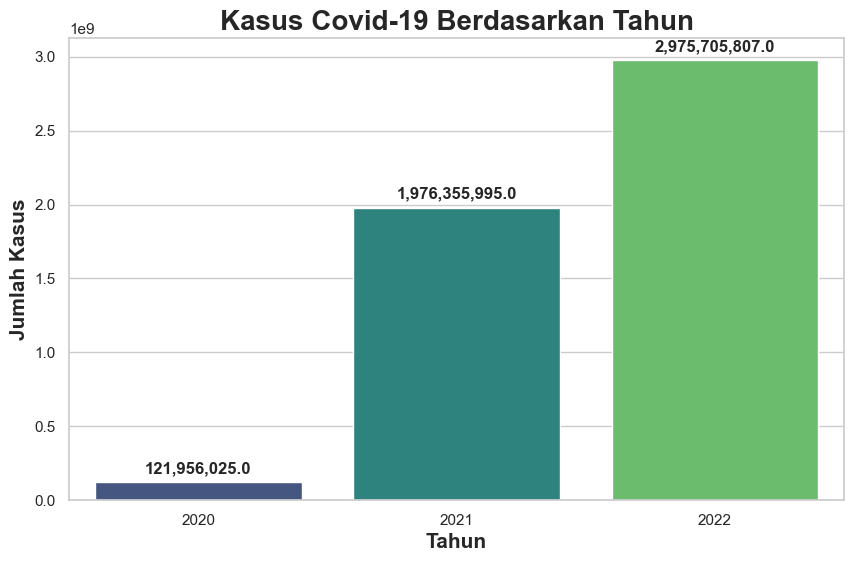

In [21]:
sns.set(style='whitegrid')

plt.figure(figsize=(10, 6))
barplot = sns.barplot(x='Year', y='Total Cases', data=kasus_tahun, palette='viridis')

plt.title('Kasus Covid-19 Berdasarkan Tahun', fontsize=20, weight='bold')
plt.xlabel('Tahun', fontsize=15, weight='bold')
plt.ylabel('Jumlah Kasus', fontsize=15, weight='bold')

for p in barplot.patches:
    barplot.annotate(format(p.get_height(), ','),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center',
                     xytext=(0, 10),
                     textcoords='offset points',
                     fontsize=12, weight='bold')


plt.show()

In [22]:
#Analisis kasus kematian akibat covid-19 berdasarkan Tahun
kematian_tahun = filled_data.groupby('Year')['Total Deaths'].sum().reset_index()
print(kematian_tahun)

   Year  Total Deaths
0  2020       4464047
1  2021      61392893
2  2022      79402637


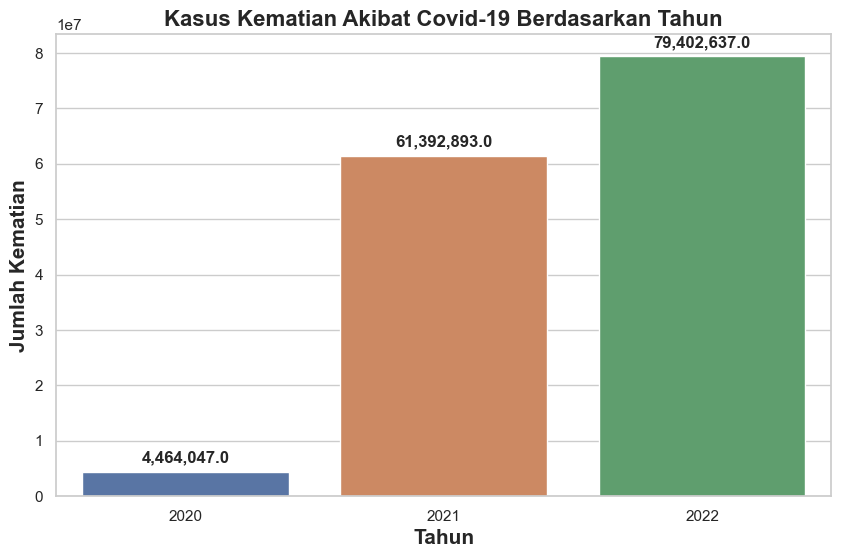

In [23]:
sns.set(style='whitegrid')

plt.figure(figsize=(10, 6))
barplot = sns.barplot(x='Year', y='Total Deaths', data=kematian_tahun, palette='deep')

plt.title('Kasus Kematian Akibat Covid-19 Berdasarkan Tahun', fontsize=16, weight='bold')
plt.xlabel('Tahun', fontsize=15, weight='bold')
plt.ylabel('Jumlah Kematian', fontsize=15, weight='bold')

for p in barplot.patches:
    barplot.annotate(format(p.get_height(), ','),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center',
                     xytext=(0, 10),
                     textcoords='offset points',
                     fontsize=12, weight='bold')


plt.show()

In [24]:
#Analisis kesembuhan Covid-19 berdasarkan Tahun
kesembuhan_tahun = filled_data.groupby('Year')['Total Recovered'].sum().reset_index()
print(kesembuhan_tahun)

   Year  Total Recovered
0  2020         94092281
1  2021       1809923761
2  2022       2845782204


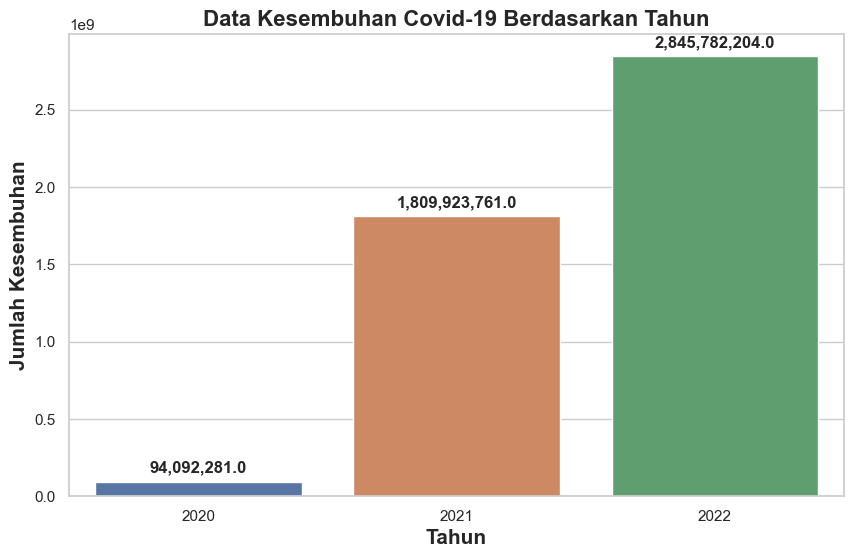

In [25]:
sns.set(style='whitegrid')

plt.figure(figsize=(10, 6))
barplot = sns.barplot(x='Year', y='Total Recovered', data=kesembuhan_tahun, palette='deep')

plt.title('Data Kesembuhan Covid-19 Berdasarkan Tahun', fontsize=16, weight='bold')
plt.xlabel('Tahun', fontsize=15, weight='bold')
plt.ylabel('Jumlah Kesembuhan', fontsize=15, weight='bold')

for p in barplot.patches:
    barplot.annotate(format(p.get_height(), ','),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center',
                     xytext=(0, 10),
                     textcoords='offset points',
                     fontsize=12, weight='bold')


plt.show()

In [26]:
num_col = filled_data.select_dtypes(include=['number']).columns.tolist()

In [27]:
#Perbandingan antara jumlah kematian dan kesembuhan Covid-19
compare_df = filled_data.groupby('Year')[num_col].sum()[['Total Deaths', 'Total Recovered']].reset_index()

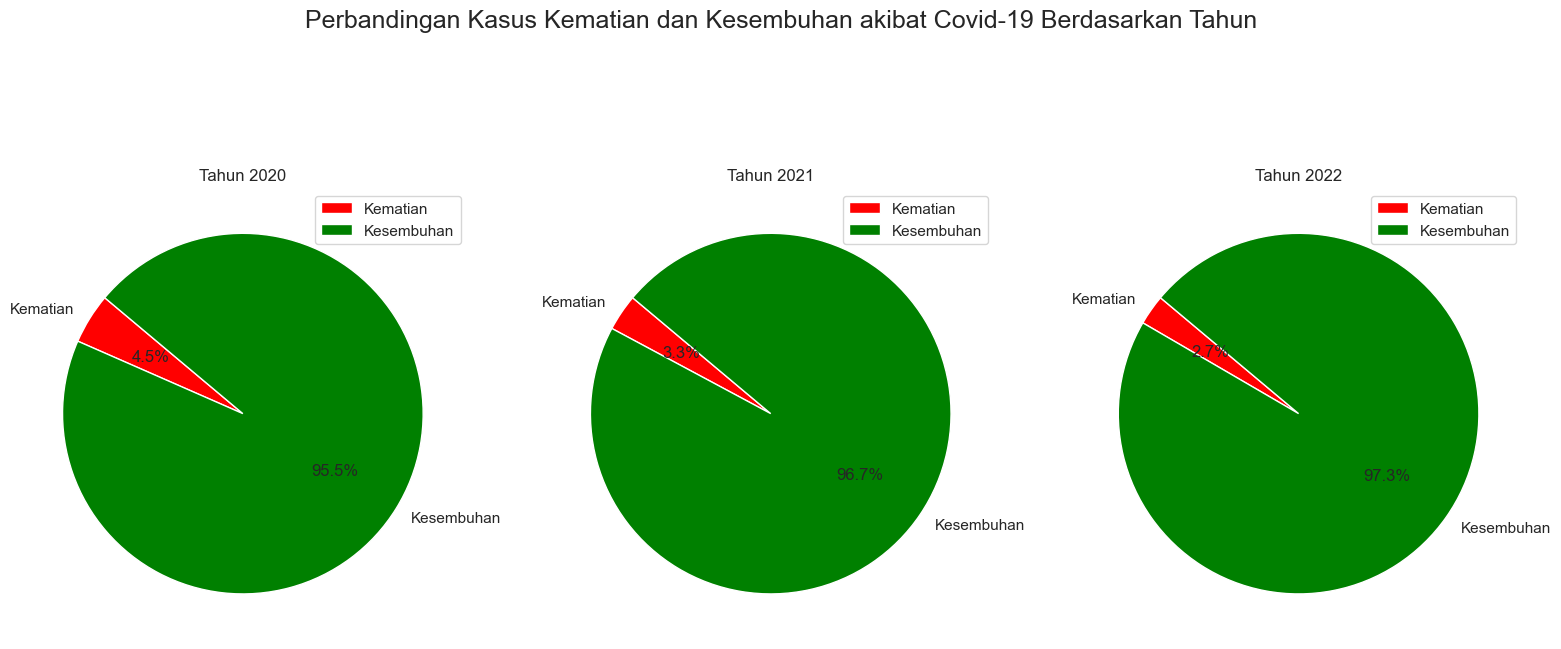

In [28]:
fig, ax = plt.subplots(1, 3, figsize=(16, 8))

labels = ['Kematian', 'Kesembuhan']
sizes = [compare_df.loc[compare_df['Year'] == 2020, 'Total Deaths'].values[0], compare_df.loc[compare_df['Year'] == 2020, 'Total Recovered'].values[0]]
ax[0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=['red', 'green'])
ax[0].legend()
ax[0].set_title('Tahun 2020')

labels = ['Kematian', 'Kesembuhan']
sizes = [compare_df.loc[compare_df['Year'] == 2021, 'Total Deaths'].values[0], compare_df.loc[compare_df['Year'] == 2021, 'Total Recovered'].values[0]]
ax[1].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=['red', 'green'])
ax[1].legend()
ax[1].set_title('Tahun 2021')

labels = ['Kematian', 'Kesembuhan']
sizes = [compare_df.loc[compare_df['Year'] == 2022, 'Total Deaths'].values[0], compare_df.loc[compare_df['Year'] == 2022, 'Total Recovered'].values[0]]
ax[2].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=['red', 'green'])
ax[2].legend()
ax[2].set_title('Tahun 2022')

fig.suptitle('Perbandingan Kasus Kematian dan Kesembuhan akibat Covid-19 Berdasarkan Tahun', fontsize=18)
plt.tight_layout()
plt.show()

In [29]:
#Analisis kasus Covid-19 di berbagai pulau di Indonesia
island_case = filled_data.groupby('Island')['Total Cases'].sum().reset_index()
island_case

,Island,Total Cases
0,Jawa,1684649515
1,Kalimantan,2736245238
2,Maluku,15828640
3,Nusa Tenggara,116845418
4,Papua,35920096
5,Sulawesi,138687078
6,Sumatera,345841842


In [30]:
island_case2 = filled_data.groupby('Island')['Total Cases'].sum()

explode = [0.05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
value = list(island_case2.values)
label = list(island_case2.index)

print(value)
print(label)

[1684649515, 2736245238, 15828640, 116845418, 35920096, 138687078, 345841842]
['Jawa', 'Kalimantan', 'Maluku', 'Nusa Tenggara', 'Papua', 'Sulawesi', 'Sumatera']


In [31]:
color = ['DeepSkyBlue', 'limegreen', 'coral', 'Orchid', 'Yellow', 'MediumVioletRed', 'aquamarine']
fig = ply.graph_objs.Figure (
    data=[
        ply.graph_objs.Pie(labels=label, values=value, pull=explode, marker=dict(colors=color))]
    )
fig.update_layout(title= 'Total Kasus Covid-19 di Indonesia berdasarkan Pulau', autosize=True)
fig.show()

In [32]:
#Analisis kasus kematian dan kesembuhan akibat Covid-19 di berbagai pulau
rec_island = filled_data.groupby('Island')['Total Recovered'].sum().reset_index()
print(rec_island)

print()
death_island = filled_data.groupby('Island')['Total Deaths'].sum().reset_index()
print(death_island)

          Island  Total Recovered
0           Jawa       1580711837
1     Kalimantan       2561481842
2         Maluku         14719392
3  Nusa Tenggara        109623384
4          Papua         31123634
5       Sulawesi        130408749
6       Sumatera        321729408

          Island  Total Deaths
0           Jawa      49037752
1     Kalimantan      77984333
2         Maluku        314707
3  Nusa Tenggara       3122514
4          Papua        488291
5       Sulawesi       3228291
6       Sumatera      11083689


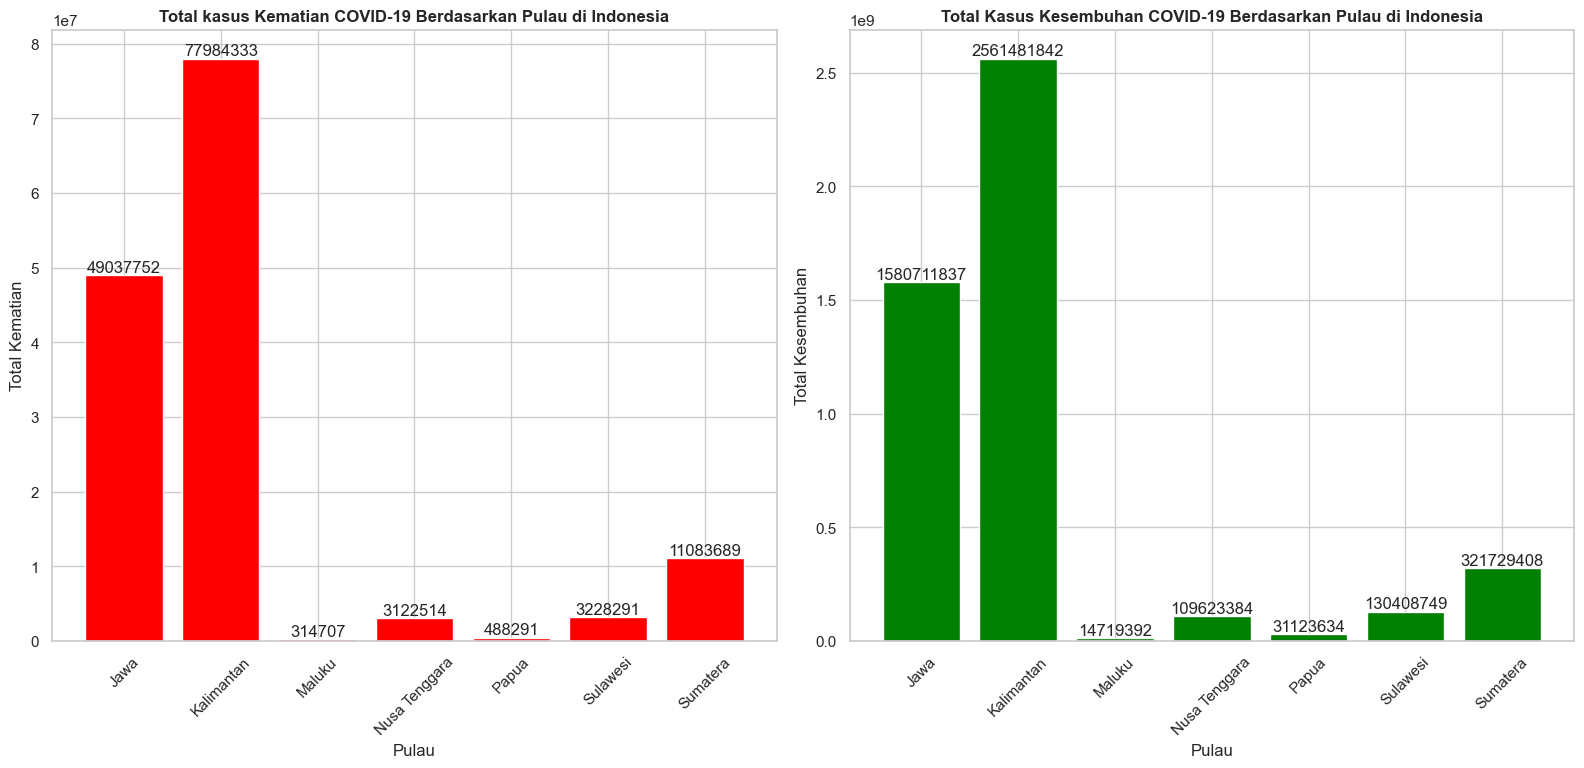

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

bar1 = ax[0].bar(death_island['Island'], death_island['Total Deaths'], color='red')
ax[0].set_title('Total kasus Kematian COVID-19 Berdasarkan Pulau di Indonesia', weight='bold')
ax[0].set_xlabel('Pulau')
ax[0].set_ylabel('Total Kematian')
ax[0].tick_params(axis='x', rotation=45)

for bar in bar1:
    yval = bar.get_height() 
    xpos = bar.get_x() + bar.get_width() / 2 
    ax[0].text(xpos, yval, f'{yval}', ha='center', va='bottom')

bar2 = ax[1].bar(rec_island['Island'], rec_island['Total Recovered'], color='green')
ax[1].set_title('Total Kasus Kesembuhan COVID-19 Berdasarkan Pulau di Indonesia', weight='bold')
ax[1].set_xlabel('Pulau')
ax[1].set_ylabel('Total Kesembuhan')
ax[1].tick_params(axis='x', rotation=45)

for bar in bar2:
    yval = bar.get_height()
    xpos = bar.get_x() + bar.get_width() / 2
    ax[1].text(xpos, yval, f'{yval}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [79]:
#Analisis Perbandingan Provinsi dengan Kasus Terjangkit, Kematian dan Kesembuhan akibat Covid-19 Tertinggi dan Terendah
cases_pv = filled_data.groupby('Province')['Total Cases'].sum().reset_index()
print(cases_pv)

rec_pv = filled_data.groupby('Province')['Total Recovered'].sum().reset_index()
print('\n', rec_pv)

deaths_pv = filled_data.groupby('Province')['Total Deaths'].sum().reset_index()
print('\n', deaths_pv)

                      Province  Total Cases
0                         Aceh     19962180
1                         Bali     66247623
2                       Banten    100598017
3                     Bengkulu     12347482
4                  DKI Jakarta    545806047
5   Daerah Istimewa Yogyakarta     86090207
6                    Gorontalo      6746166
7                        Jambi     15700629
8                   Jawa Barat    439196053
9                  Jawa Tengah    273046506
10                  Jawa Timur    239912685
11            Kalimantan Barat     23403342
12          Kalimantan Selatan     39485248
13           Kalimantan Tengah   2564991545
14            Kalimantan Timur     89582475
15            Kalimantan Utara     18782628
16   Kepulauan Bangka Belitung     26613493
17              Kepulauan Riau     29043850
18                     Lampung     28891786
19                      Maluku      9046656
20                Maluku Utara      6781984
21         Nusa Tenggara Barat  

In [82]:
sorted_cases = cases_pv.sort_values(by='Total Cases', ascending=False)
print(sorted_cases)

sorted_rec = rec_pv.sort_values(by='Total Recovered', ascending=False)
print('\n', sorted_rec)

sorted_deaths = deaths_pv.sort_values(by='Total Deaths', ascending=False)
print('\n', sorted_deaths)

                      Province  Total Cases
13           Kalimantan Tengah   2564991545
4                  DKI Jakarta    545806047
8                   Jawa Barat    439196053
9                  Jawa Tengah    273046506
10                  Jawa Timur    239912685
2                       Banten    100598017
14            Kalimantan Timur     89582475
5   Daerah Istimewa Yogyakarta     86090207
25                        Riau     68594950
27            Sulawesi Selatan     66922249
1                         Bali     66247623
33              Sumatera Utara     60912221
31              Sumatera Barat     49292155
12          Kalimantan Selatan     39485248
22         Nusa Tenggara Timur     34710372
32            Sumatera Selatan     34483096
17              Kepulauan Riau     29043850
18                     Lampung     28891786
16   Kepulauan Bangka Belitung     26613493
28             Sulawesi Tengah     24193556
11            Kalimantan Barat     23403342
23                       Papua  

In [83]:
top_cases = sorted_cases.head(1)
bot_cases = sorted_cases.tail(1)

top_rec = sorted_rec.head(1)
bot_rec = sorted_rec.tail(1)

top_deaths = sorted_deaths.head(1)
bot_deaths = sorted_deaths.tail(1)

print('Provinsi dengan Kasus Covid-19 Tertinggi:')
print(top_cases)
print('\nProvinsi dengan Kasus Covid-19 Terendah:')
print(bot_cases)

print('\n\n')
print('Provinsi dengan Kesembuhan Covid-19 Tertinggi:')
print(top_rec)
print('\nProvinsi dengan Kesembuhan Covid-19 Terendah:')
print(bot_rec)

print('\n\n')
print('Provinsi dengan Kasus Kematian Covid-19 Tertinggi:')
print(top_deaths)
print('\nProvinsi dengan Kasus Kematian Covid-19 Terendah:')
print(bot_deaths)

Provinsi dengan Kasus Covid-19 Tertinggi:
             Province  Total Cases
13  Kalimantan Tengah   2564991545

Provinsi dengan Kasus Covid-19 Terendah:
    Province  Total Cases
6  Gorontalo      6746166



Provinsi dengan Kesembuhan Covid-19 Tertinggi:
             Province  Total Recovered
13  Kalimantan Tengah       2400365307

Provinsi dengan Kesembuhan Covid-19 Terendah:
        Province  Total Recovered
20  Maluku Utara          6292555



Provinsi dengan Kasus Kematian Covid-19 Tertinggi:
             Province  Total Deaths
13  Kalimantan Tengah      73246773

Provinsi dengan Kasus Kematian Covid-19 Terendah:
   Province  Total Deaths
19   Maluku        147196


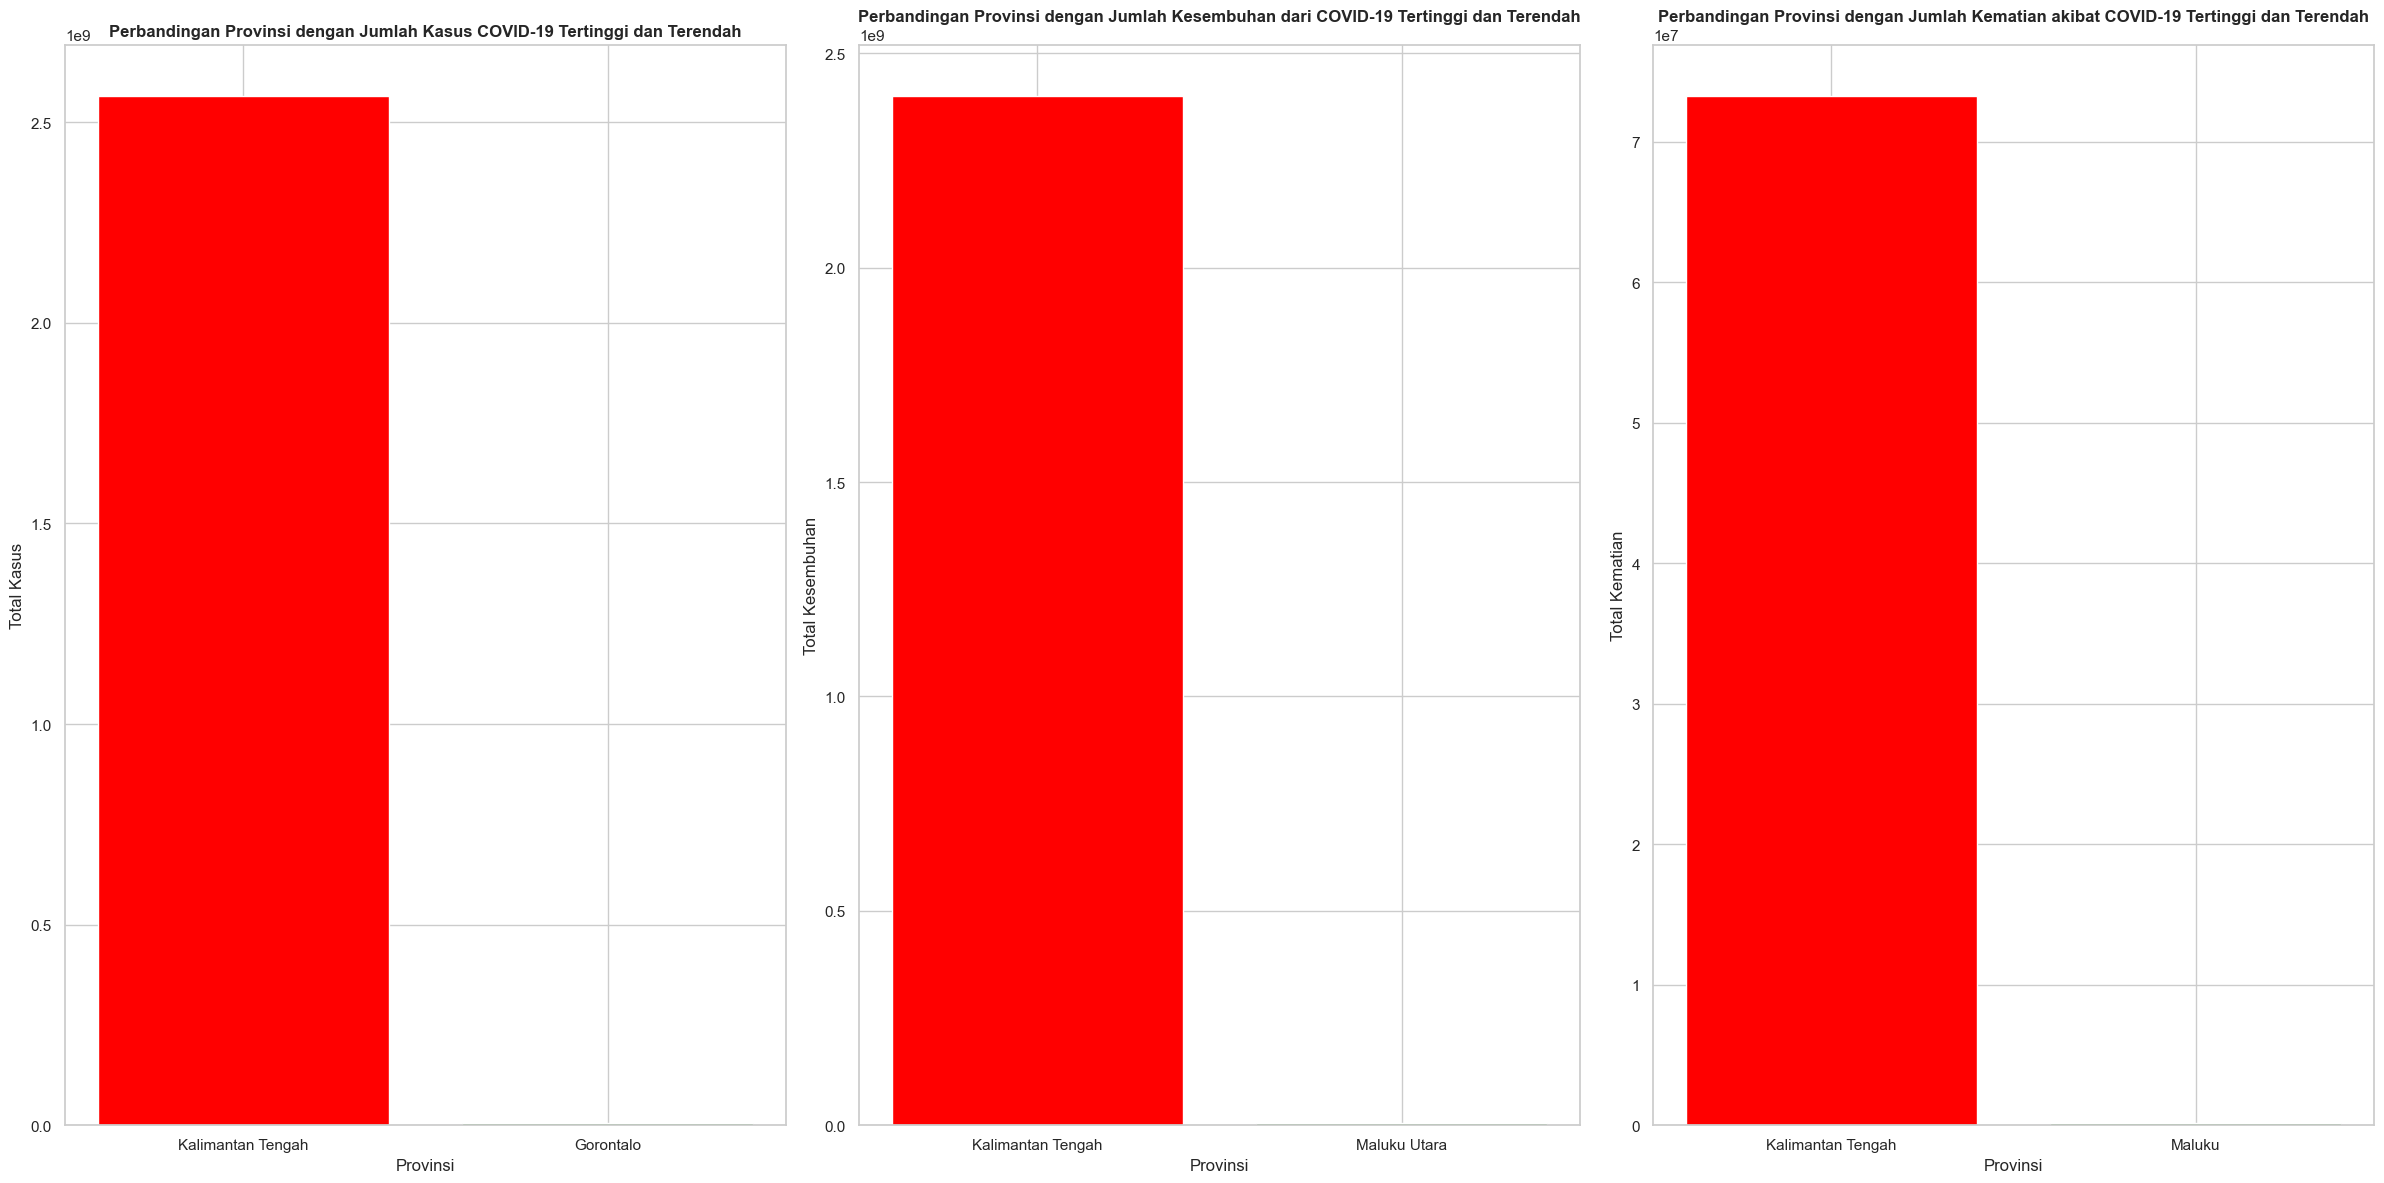

In [91]:
fig, ax = plt.subplots(1, 3, figsize=(24, 12))

ax[0].bar(top_cases['Province'], top_cases['Total Cases'], color='red')
ax[0].bar(bot_cases['Province'], bot_cases['Total Cases'], color='green')
ax[0].set_title('Perbandingan Provinsi dengan Jumlah Kasus COVID-19 Tertinggi dan Terendah', weight='bold')
ax[0].set_xlabel('Provinsi')
ax[0].set_ylabel('Total Kasus')
ax[0].tick_params(axis='x', rotation=0)

ax[1].bar(top_rec['Province'], top_rec['Total Recovered'], color='red')
ax[1].bar(bot_rec['Province'], bot_rec['Total Recovered'], color='green')
ax[1].set_title('Perbandingan Provinsi dengan Jumlah Kesembuhan dari COVID-19 Tertinggi dan Terendah', weight='bold')
ax[1].set_xlabel('Provinsi')
ax[1].set_ylabel('Total Kesembuhan')
ax[1].tick_params(axis='x', rotation=0)

ax[2].bar(top_deaths['Province'], top_deaths['Total Deaths'], color='red')
ax[2].bar(bot_deaths['Province'], bot_deaths['Total Deaths'], color='green')
ax[2].set_title('Perbandingan Provinsi dengan Jumlah Kematian akibat COVID-19 Tertinggi dan Terendah', weight='bold')
ax[2].set_xlabel('Provinsi')
ax[2].set_ylabel('Total Kematian')
ax[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()